# D04 – Data Visualisation
## The "Value-for-Money" Transfer Scout
*Group 7: Megann Kouandjeu, Salma Kamoun, Axel Chartier*

---

### Overview

This deliverable produces **three publication-quality plots**, one per required category:

| Plot | Category | Title | Data Source |
|---|---|---|---|
| 1 | Original data | *The Transfer Market Landscape* | `master_training_data.csv` (D01) |
| 2 | Feature-engineered data | *The Impact of Feature Engineering* | `df_engineered_outfield.csv` (D02) |
| 3 | Model performance | *Model Comparison Dashboard* | D03 trained models |

Each plot is designed to communicate a **specific insight** rather than simply reproduce summary statistics. The choice of chart types is motivated by the data properties identified across D01–D03.

---
## 0. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, r2_score, mean_squared_log_error

import warnings
warnings.filterwarnings('ignore')

# ── Project colour palette ──────────────────────────────────────────────────
C_RIDGE = '#3498db'   # Blue   — Ridge Regression
C_RF    = '#e67e22'   # Orange — Random Forest
C_XGB   = '#27ae60'   # Green  — XGBoost
C_POS   = {'GK':'#9b59b6','DEF':'#3498db','MID':'#2ecc71','WNG':'#f39c12','ATT':'#e74c3c'}

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 120,
})

print('Setup complete.')

Setup complete.


---
## 1. Load Datasets

In [13]:
# D01 output — raw master dataset
df_raw = pd.read_csv(r'..\datasets\master_training_data.csv')

# D02 output — feature-engineered outfield dataset
df_eng = pd.read_csv(r'..\datasets\df_engineered_outfield.csv')
# Fill any NaN records with 0 so the Ridge model can compute predictions without crashing
df_eng = df_eng.fillna(0)

print(f'Raw master (D01)       : {df_raw.shape}  → columns: {df_raw.columns.tolist()}')
print(f'Engineered outfield (D02): {df_eng.shape}')


Raw master (D01)       : (23459, 10)  → columns: ['player_id', 'market_value_eur', 'age', 'height', 'position', 'foot', 'minutes_played', 'goals', 'assists', 'days_missed']
Engineered outfield (D02): (20714, 37)


---
## Plot 1 — Original Data: *The Transfer Market Landscape*

### Design rationale

D01's EDA produced three basic charts: a log-scale histogram, an age scatter plot, and a correlation heatmap. Plot 1 extends this into a **single cohesive 2×2 figure** that tells the full story of the raw data's structural properties — the ones that motivated every major modelling decision in D02 and D03.

| Panel | What it shows | Why it matters |
|---|---|---|
| A — Top left | Market value distribution with mean/median annotations | Quantifies the right-skew (skewness = 10.32) that motivated the log transform in D02 |
| B — Top right | Market value by position (violin plot) | Shows that positional premiums are real and non-linear — justifies the one-hot position encoding in D02 |
| C — Bottom left | Age vs market value with median trend line | Confirms the inverted-U non-linearity that motivated `age_squared` and `prime_age_flag` in D02 and the choice of non-linear models in D03 |
| D — Bottom right | Raw feature correlation with market value (bar chart) | Shows the D01 finding that `assists` (0.29) and `goals` (0.24) are the strongest raw signals — and that `age` appears near-zero due to the non-linearity |

**Chart type choices:** Violin plots over boxplots for Panel B — violin plots show the full value distribution per position, not just quartiles, which is important because positional value distributions are multi-modal (e.g., DEF has a bimodal distribution: average centre-backs vs elite ones). A KDE trend over raw scatter for Panel C reduces overplotting at the dense lower-value region.

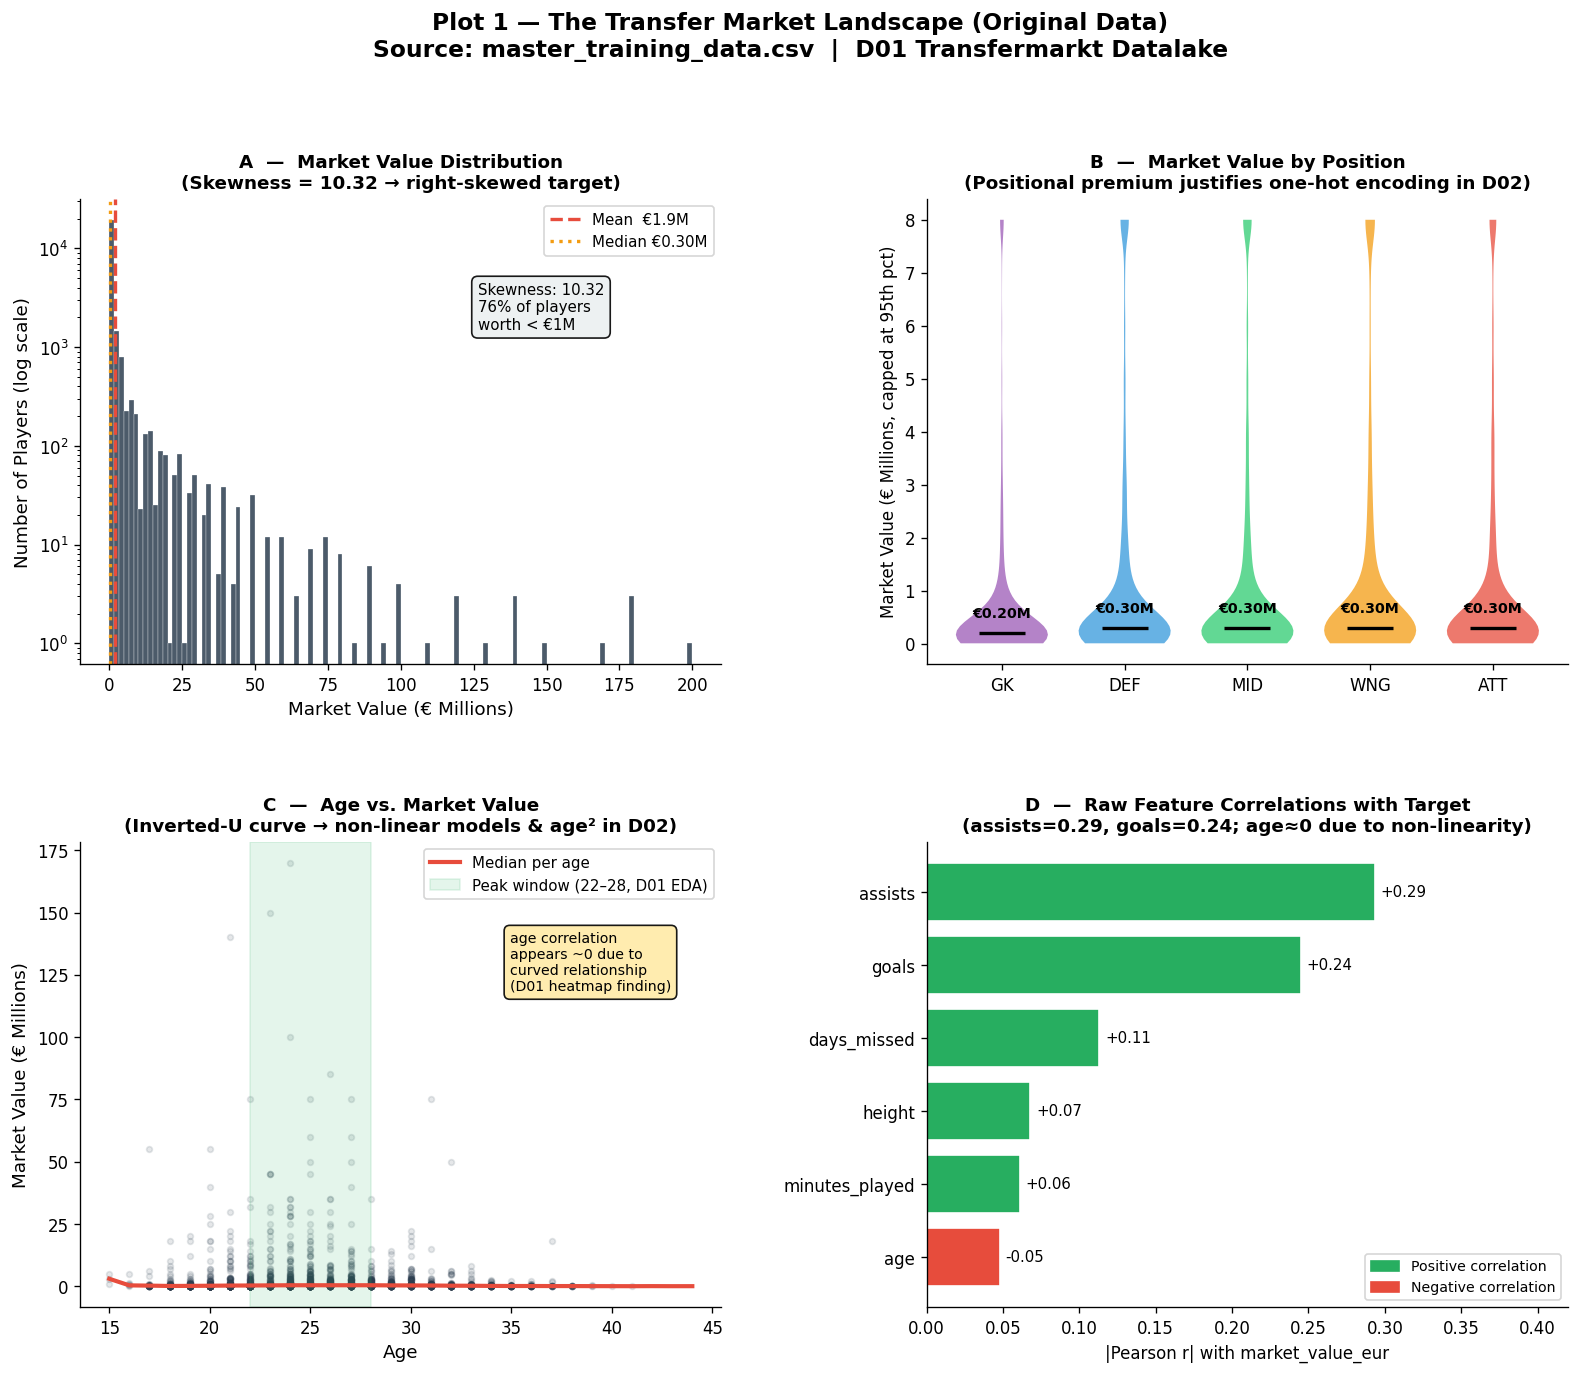

Plot 1 saved.


In [10]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax_A = fig.add_subplot(gs[0, 0])   # Market value distribution
ax_B = fig.add_subplot(gs[0, 1])   # Value by position
ax_C = fig.add_subplot(gs[1, 0])   # Age vs value
ax_D = fig.add_subplot(gs[1, 1])   # Raw feature correlations

# ── Panel A: Market Value Distribution ─────────────────────────────────────
mv = df_raw['market_value_eur'] / 1e6
ax_A.hist(mv, bins=120, color='#2c3e50', edgecolor='white', linewidth=0.2, alpha=0.85)
ax_A.set_yscale('log')

mean_v   = mv.mean()
median_v = mv.median()
ax_A.axvline(mean_v,   color='#e74c3c', linewidth=2,   linestyle='--', label=f'Mean  €{mean_v:.1f}M')
ax_A.axvline(median_v, color='#f39c12', linewidth=2,   linestyle=':',  label=f'Median €{median_v:.2f}M')

ax_A.set_xlabel('Market Value (€ Millions)', fontsize=11)
ax_A.set_ylabel('Number of Players (log scale)', fontsize=11)
ax_A.set_title('A  —  Market Value Distribution\n(Skewness = 10.32 → right-skewed target)', fontsize=11, fontweight='bold')
ax_A.legend(fontsize=9)
skew_txt = f'Skewness: {mv.skew():.2f}\n{(mv < 1).mean()*100:.0f}% of players\nworth < €1M'
ax_A.annotate(skew_txt, xy=(0.62, 0.72), xycoords='axes fraction', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

# ── Panel B: Market Value by Position (Violin) ─────────────────────────────
# Map raw position to 5-group for this plot
def pos_group(p):
    if 'Goalkeeper' in str(p): return 'GK'
    elif 'Back' in str(p):     return 'DEF'
    elif 'Midfield' in str(p) or 'Defensive' in str(p): return 'MID'
    elif 'Winger' in str(p) or 'Second Striker' in str(p): return 'WNG'
    else: return 'ATT'

df_raw['pos_group'] = df_raw['position'].apply(pos_group)
pos_order = ['GK', 'DEF', 'MID', 'WNG', 'ATT']
pos_colors = [C_POS[p] for p in pos_order]

# Clip at 95th pct for readability
cap = df_raw['market_value_eur'].quantile(0.95) / 1e6
plot_df = df_raw.copy()
plot_df['mv_M'] = (plot_df['market_value_eur'] / 1e6).clip(upper=cap)

parts = ax_B.violinplot(
    [plot_df.loc[plot_df['pos_group']==p, 'mv_M'].values for p in pos_order],
    positions=range(len(pos_order)),
    showmedians=True, showextrema=False, widths=0.75
)
for pc, col in zip(parts['bodies'], pos_colors):
    pc.set_facecolor(col)
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

medians = [plot_df.loc[plot_df['pos_group']==p, 'mv_M'].median() for p in pos_order]
for i, (p, med) in enumerate(zip(pos_order, medians)):
    ax_B.text(i, med + cap*0.03, f'€{med:.2f}M', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax_B.set_xticks(range(len(pos_order)))
ax_B.set_xticklabels(pos_order, fontsize=10)
ax_B.set_ylabel('Market Value (€ Millions, capped at 95th pct)', fontsize=10)
ax_B.set_title('B  —  Market Value by Position\n(Positional premium justifies one-hot encoding in D02)', fontsize=11, fontweight='bold')

# ── Panel C: Age vs Market Value with Trend ─────────────────────────────────
sample = df_raw.sample(min(3000, len(df_raw)), random_state=42)
ax_C.scatter(sample['age'], sample['market_value_eur']/1e6,
             alpha=0.12, s=12, color='#2c3e50')

# Median trend line
age_med = df_raw.groupby('age')['market_value_eur'].median() / 1e6
ax_C.plot(age_med.index, age_med.values, color='#e74c3c', linewidth=2.5, zorder=5, label='Median per age')
ax_C.axvspan(22, 28, alpha=0.12, color='#27ae60', label='Peak window (22–28, D01 EDA)')

ax_C.set_xlabel('Age', fontsize=11)
ax_C.set_ylabel('Market Value (€ Millions)', fontsize=11)
ax_C.set_title('C  —  Age vs. Market Value\n(Inverted-U curve → non-linear models & age² in D02)', fontsize=11, fontweight='bold')
ax_C.legend(fontsize=9)
ax_C.annotate('age correlation\nappears ~0 due to\ncurved relationship\n(D01 heatmap finding)',
              xy=(0.67, 0.68), xycoords='axes fraction', fontsize=8.5,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', alpha=0.9))

# ── Panel D: Raw Feature Correlations with Target ──────────────────────────
raw_num = ['age', 'height', 'minutes_played', 'goals', 'assists', 'days_missed']
raw_num = [c for c in raw_num if c in df_raw.columns]
corrs = df_raw[raw_num].corrwith(df_raw['market_value_eur'])
corrs_sorted = corrs.abs().sort_values()

bar_colors = ['#e74c3c' if corrs[f] < 0 else '#27ae60' for f in corrs_sorted.index]
bars = ax_D.barh(corrs_sorted.index, corrs_sorted.values, color=bar_colors, edgecolor='white')

# Annotate with actual signed correlation
for bar, feat in zip(bars, corrs_sorted.index):
    signed = corrs[feat]
    ax_D.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
              f'{signed:+.2f}', va='center', fontsize=9)

ax_D.set_xlabel('|Pearson r| with market_value_eur', fontsize=10)
ax_D.set_title('D  —  Raw Feature Correlations with Target\n(assists=0.29, goals=0.24; age≈0 due to non-linearity)', fontsize=11, fontweight='bold')
ax_D.set_xlim(0, 0.42)

green_p = mpatches.Patch(color='#27ae60', label='Positive correlation')
red_p   = mpatches.Patch(color='#e74c3c', label='Negative correlation')
ax_D.legend(handles=[green_p, red_p], fontsize=8.5, loc='lower right')

# ── Figure title ────────────────────────────────────────────────────────────
fig.suptitle(
    'Plot 1 — The Transfer Market Landscape (Original Data)\n'
    'Source: master_training_data.csv  |  D01 Transfermarkt Datalake',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig(r'..\plots\plot1_original_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved.')

---
## Plot 2 — Feature-Engineered Data: *The Impact of Feature Engineering*

### Design rationale

Plot 2 must show something the raw data plot cannot: **what changed after D02's engineering pipeline, and why those changes matter for modelling.** It is not about showing features in isolation, but about showing the *before/after contrast* and the *new signal quality* that engineering unlocked.

| Panel | What it shows | Engineering decision it validates |
|---|---|---|
| A — Top left | Before vs after log transform (overlaid KDE) | D02 §2: log1p reduces skewness from 10.32 to ~1.x |
| B — Top right | Raw `goals` vs `goals_per_90` correlation with target | D02 §4: rate normalisation improves signal quality |
| C — Bottom left | `goal_contributions_per_90` distribution by position group | D02 §4 + §8: shows GK split importance and positional attack patterns |
| D — Bottom right | Engineered feature correlations with `log_market_value` — ranked | D02 §13: validates the hypothesised importance ranking |

**Chart type choices:** Overlaid KDE (Panel A) makes the before/after contrast sharp and readable. A paired bar chart (Panel B) communicates the correlation improvement clearly. A grouped KDE / ridgeline style (Panel C) naturally shows distributional differences across position groups without overcrowding.

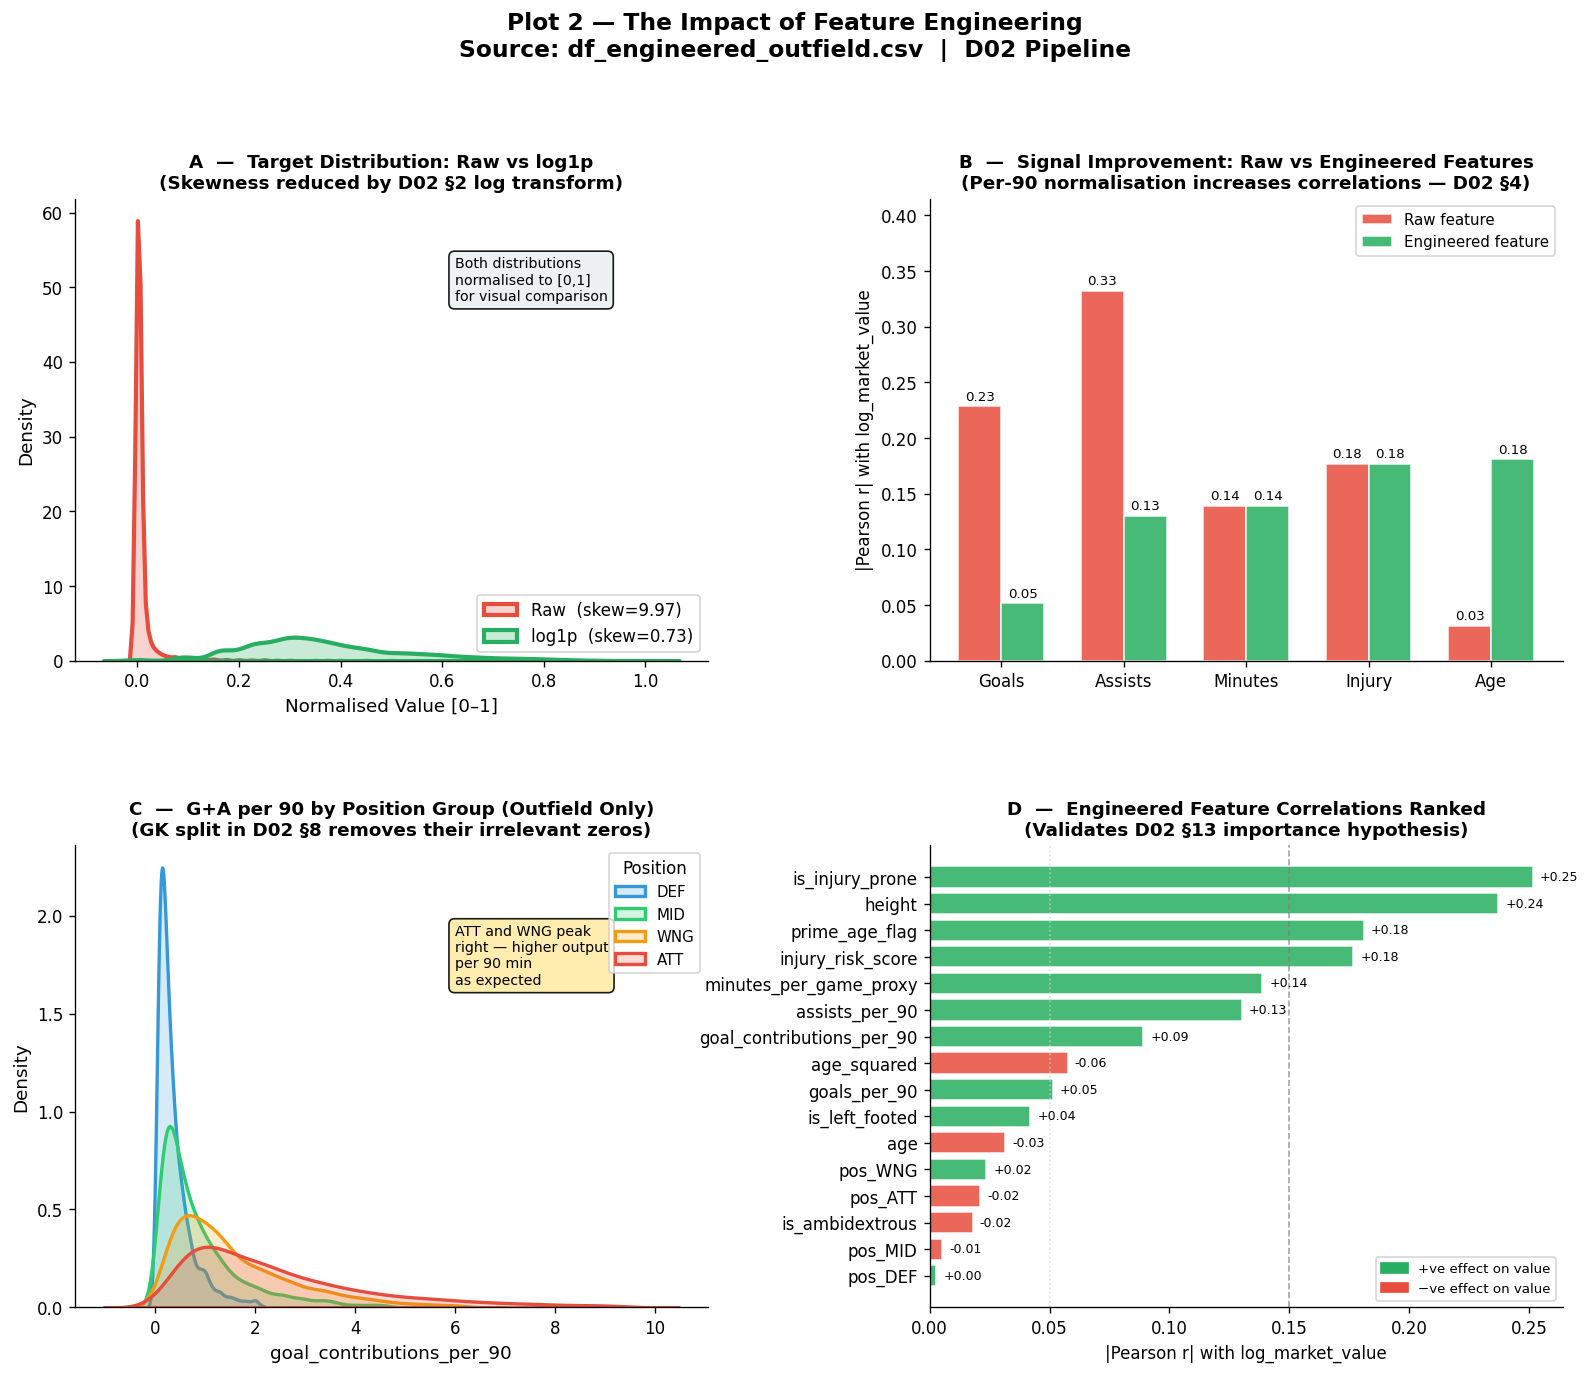

Plot 2 saved.


In [11]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1])
ax_C = fig.add_subplot(gs[1, 0])
ax_D = fig.add_subplot(gs[1, 1])

# ── Panel A: Log Transform — Before vs After ────────────────────────────────
raw_vals = df_eng['market_value_eur'] / 1e6
log_vals = df_eng['log_market_value']

# Normalise both to the same 0-1 x-axis range for overlay
raw_norm = (raw_vals - raw_vals.min()) / (raw_vals.max() - raw_vals.min())
log_norm = (log_vals - log_vals.min()) / (log_vals.max() - log_vals.min())

sns.kdeplot(raw_norm, ax=ax_A, color='#e74c3c', linewidth=2.5, fill=True, alpha=0.25, label=f'Raw  (skew={raw_vals.skew():.2f})')
sns.kdeplot(log_norm, ax=ax_A, color='#27ae60', linewidth=2.5, fill=True, alpha=0.25, label=f'log1p  (skew={log_vals.skew():.2f})')

ax_A.set_xlabel('Normalised Value [0–1]', fontsize=11)
ax_A.set_ylabel('Density', fontsize=11)
ax_A.set_title('A  —  Target Distribution: Raw vs log1p\n(Skewness reduced by D02 §2 log transform)', fontsize=11, fontweight='bold')
ax_A.legend(fontsize=10)
ax_A.annotate('Both distributions\nnormalised to [0,1]\nfor visual comparison',
              xy=(0.60, 0.78), xycoords='axes fraction', fontsize=8.5,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

# ── Panel B: Correlation Improvement — Raw vs Engineered Features ──────────
# Compare correlations of raw vs engineered features with log_market_value
pairs = [
    ('goals',                    'goals_per_90',              'Goals'),
    ('assists',                  'assists_per_90',            'Assists'),
    ('minutes_played',           'minutes_per_game_proxy',    'Minutes'),
    ('days_missed',              'injury_risk_score',         'Injury'),
    ('age',                      'prime_age_flag',            'Age'),
]

labels, raw_corr, eng_corr = [], [], []
for raw_col, eng_col, label in pairs:
    if raw_col in df_eng.columns and eng_col in df_eng.columns:
        labels.append(label)
        raw_corr.append(abs(df_eng[raw_col].corr(df_eng['log_market_value'])))
        eng_corr.append(abs(df_eng[eng_col].corr(df_eng['log_market_value'])))

x      = np.arange(len(labels))
width  = 0.35
bars_r = ax_B.bar(x - width/2, raw_corr, width, label='Raw feature',        color='#e74c3c', alpha=0.85, edgecolor='white')
bars_e = ax_B.bar(x + width/2, eng_corr, width, label='Engineered feature', color='#27ae60', alpha=0.85, edgecolor='white')

for bar in bars_r:
    ax_B.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{bar.get_height():.2f}',
              ha='center', va='bottom', fontsize=8)
for bar in bars_e:
    ax_B.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{bar.get_height():.2f}',
              ha='center', va='bottom', fontsize=8)

ax_B.set_xticks(x)
ax_B.set_xticklabels(labels, fontsize=10)
ax_B.set_ylabel('|Pearson r| with log_market_value', fontsize=10)
ax_B.set_title('B  —  Signal Improvement: Raw vs Engineered Features\n(Per-90 normalisation increases correlations — D02 §4)', fontsize=11, fontweight='bold')
ax_B.legend(fontsize=9)
ax_B.set_ylim(0, max(max(raw_corr), max(eng_corr)) * 1.25)

# ── Panel C: goal_contributions_per_90 Distribution by Position Group ──────
pos_order_out = ['DEF', 'MID', 'WNG', 'ATT']
pos_colors_out = [C_POS[p] for p in pos_order_out]

for pos, col in zip(pos_order_out, pos_colors_out):
    subset = df_eng.loc[df_eng['position_group'] == pos, 'goal_contributions_per_90']
    subset = subset[subset < subset.quantile(0.98)]  # clip extreme outliers
    sns.kdeplot(subset, ax=ax_C, color=col, linewidth=2, fill=True, alpha=0.20, label=pos)

ax_C.set_xlabel('goal_contributions_per_90', fontsize=11)
ax_C.set_ylabel('Density', fontsize=11)
ax_C.set_title('C  —  G+A per 90 by Position Group (Outfield Only)\n(GK split in D02 §8 removes their irrelevant zeros)', fontsize=11, fontweight='bold')
ax_C.legend(title='Position', fontsize=9)
ax_C.annotate('ATT and WNG peak\nright — higher output\nper 90 min\nas expected',
              xy=(0.60, 0.70), xycoords='axes fraction', fontsize=8.5,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', alpha=0.9))

# ── Panel D: Engineered Feature Correlations Ranked ─────────────────────────
eng_features = [
    'age', 'age_squared', 'prime_age_flag', 'height',
    'goals_per_90', 'assists_per_90', 'goal_contributions_per_90',
    'minutes_per_game_proxy', 'injury_risk_score', 'is_injury_prone',
    'is_left_footed', 'is_ambidextrous',
    'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG'
]
eng_features = [c for c in eng_features if c in df_eng.columns]

corrs_eng   = df_eng[eng_features].corrwith(df_eng['log_market_value'])
corrs_abs   = corrs_eng.abs().sort_values()
bar_cols_d  = ['#27ae60' if corrs_eng[f] >= 0 else '#e74c3c' for f in corrs_abs.index]

ax_D.barh(corrs_abs.index, corrs_abs.values, color=bar_cols_d, edgecolor='white', alpha=0.85)
ax_D.axvline(0.15, color='gray',      linestyle='--', linewidth=1, alpha=0.7, label='Moderate (0.15)')
ax_D.axvline(0.05, color='lightgray', linestyle=':',  linewidth=1, alpha=0.7, label='Weak (0.05)')

for i, (feat, val) in enumerate(corrs_abs.items()):
    ax_D.text(val + 0.003, i, f'{corrs_eng[feat]:+.2f}', va='center', fontsize=7.5)

ax_D.set_xlabel('|Pearson r| with log_market_value', fontsize=10)
ax_D.set_title('D  —  Engineered Feature Correlations Ranked\n(Validates D02 §13 importance hypothesis)', fontsize=11, fontweight='bold')
ax_D.legend(fontsize=8, loc='lower right')

green_p = mpatches.Patch(color='#27ae60', label='+ve effect on value')
red_p   = mpatches.Patch(color='#e74c3c', label='−ve effect on value')
ax_D.legend(handles=[green_p, red_p], fontsize=8, loc='lower right')

# ── Figure title ─────────────────────────────────────────────────────────────
fig.suptitle(
    'Plot 2 — The Impact of Feature Engineering\n'
    'Source: df_engineered_outfield.csv  |  D02 Pipeline',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig(r'..\plots\plot2_engineered_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 saved.')

---
## Plot 3 — Model Performance: *Model Comparison Dashboard*

### Design rationale

Plot 3 must answer the question a professor or stakeholder asks when looking at model results: **"Which model is best, by how much, and can we trust its predictions?"** A single figure must communicate metric superiority, prediction quality, and where each model fails.

We first retrain all three models using the exact configurations from D03 to ensure reproducibility.

| Panel | What it shows | Why it matters |
|---|---|---|
| A — Top left | RMSLE / MAE / R² comparison (grouped bar) | Direct answer to: which model wins on D01's three metrics? |
| B — Top right | Predicted vs Actual — XGBoost only (best model) | Shows calibration quality and where errors cluster |
| C — Bottom left | Residual distribution for all 3 models (overlaid KDE) | Shows whether errors are symmetric (unbiased) or skewed (systematic mistakes) |
| D — Bottom right | XGBoost feature importance (MDI) | Validates D02 Section 13's importance hypothesis with real model output |

**Chart type choices:** Grouped bars (Panel A) allow direct metric comparison across all three models simultaneously. The predicted-vs-actual scatter (Panel B) is the gold standard for regression diagnostics. Overlaid residual KDEs (Panel C) reveal whether Ridge's errors are wider/biased relative to XGBoost — a more informative comparison than just showing RMSE numbers. Feature importance horizontal bars (Panel D) use the same visual language as D02's correlation chart, making the comparison natural.

In [14]:
# ── Retrain models (exact D03 configurations) ────────────────────────────────
df = df_eng.copy()
y  = df['log_market_value']

ridge_features = [c for c in df.columns if c.endswith('_scaled')]
binary_features = [c for c in ['prime_age_flag','is_injury_prone','is_left_footed',
                                'is_ambidextrous','pos_ATT','pos_DEF','pos_MID','pos_WNG']
                   if c in df.columns]
FEATURES_RIDGE = ridge_features + binary_features

FEATURES_TREE = [c for c in [
    'age','age_squared','prime_age_flag','height',
    'goals_per_90','assists_per_90','goal_contributions_per_90',
    'minutes_per_game_proxy','injury_risk_score','is_injury_prone',
    'is_left_footed','is_ambidextrous',
    'pos_ATT','pos_DEF','pos_MID','pos_WNG'
] if c in df.columns]

X_ridge = df[FEATURES_RIDGE]
X_tree  = df[FEATURES_TREE]

X_ridge_train, X_ridge_test, y_train, y_test = train_test_split(
    X_ridge, y, test_size=0.2, random_state=42, stratify=df['position_group']
)
train_idx = X_ridge_train.index
test_idx  = X_ridge_test.index
X_tree_train = X_tree.loc[train_idx]
X_tree_test  = X_tree.loc[test_idx]

# D03 exact model configs
ridge_model = Ridge(alpha=10)
rf_model    = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)
xgb_model   = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                             subsample=0.8, colsample_bytree=0.8,
                             reg_alpha=0.1, reg_lambda=1.0,
                             random_state=42, n_jobs=-1, verbosity=0)

ridge_model.fit(X_ridge_train, y_train)
rf_model.fit(X_tree_train, y_train)
xgb_model.fit(X_tree_train, y_train)

def get_metrics(model, X_test, y_test):
    pred_log = np.clip(model.predict(X_test), 0, None)
    pred_eur = np.expm1(pred_log)
    true_eur = np.expm1(y_test)
    rmsle = np.sqrt(mean_squared_log_error(true_eur, pred_eur))
    mae   = mean_absolute_error(true_eur, pred_eur)
    r2    = r2_score(y_test, pred_log)
    resid = pred_log - y_test.values
    return rmsle, mae, r2, pred_log, resid

r_rmsle, r_mae, r_r2, r_pred, r_resid = get_metrics(ridge_model, X_ridge_test, y_test)
f_rmsle, f_mae, f_r2, f_pred, f_resid = get_metrics(rf_model,    X_tree_test,  y_test)
x_rmsle, x_mae, x_r2, x_pred, x_resid = get_metrics(xgb_model,   X_tree_test,  y_test)

print(f'Ridge  — RMSLE: {r_rmsle:.4f} | MAE: €{r_mae/1e6:.2f}M | R²: {r_r2:.4f}')
print(f'RF     — RMSLE: {f_rmsle:.4f} | MAE: €{f_mae/1e6:.2f}M | R²: {f_r2:.4f}')
print(f'XGBoost — RMSLE: {x_rmsle:.4f} | MAE: €{x_mae/1e6:.2f}M | R²: {x_r2:.4f}')

Ridge  — RMSLE: 1.3401 | MAE: €1.68M | R²: 0.2819
RF     — RMSLE: 1.3041 | MAE: €1.66M | R²: 0.3200
XGBoost — RMSLE: 1.2976 | MAE: €1.62M | R²: 0.3268


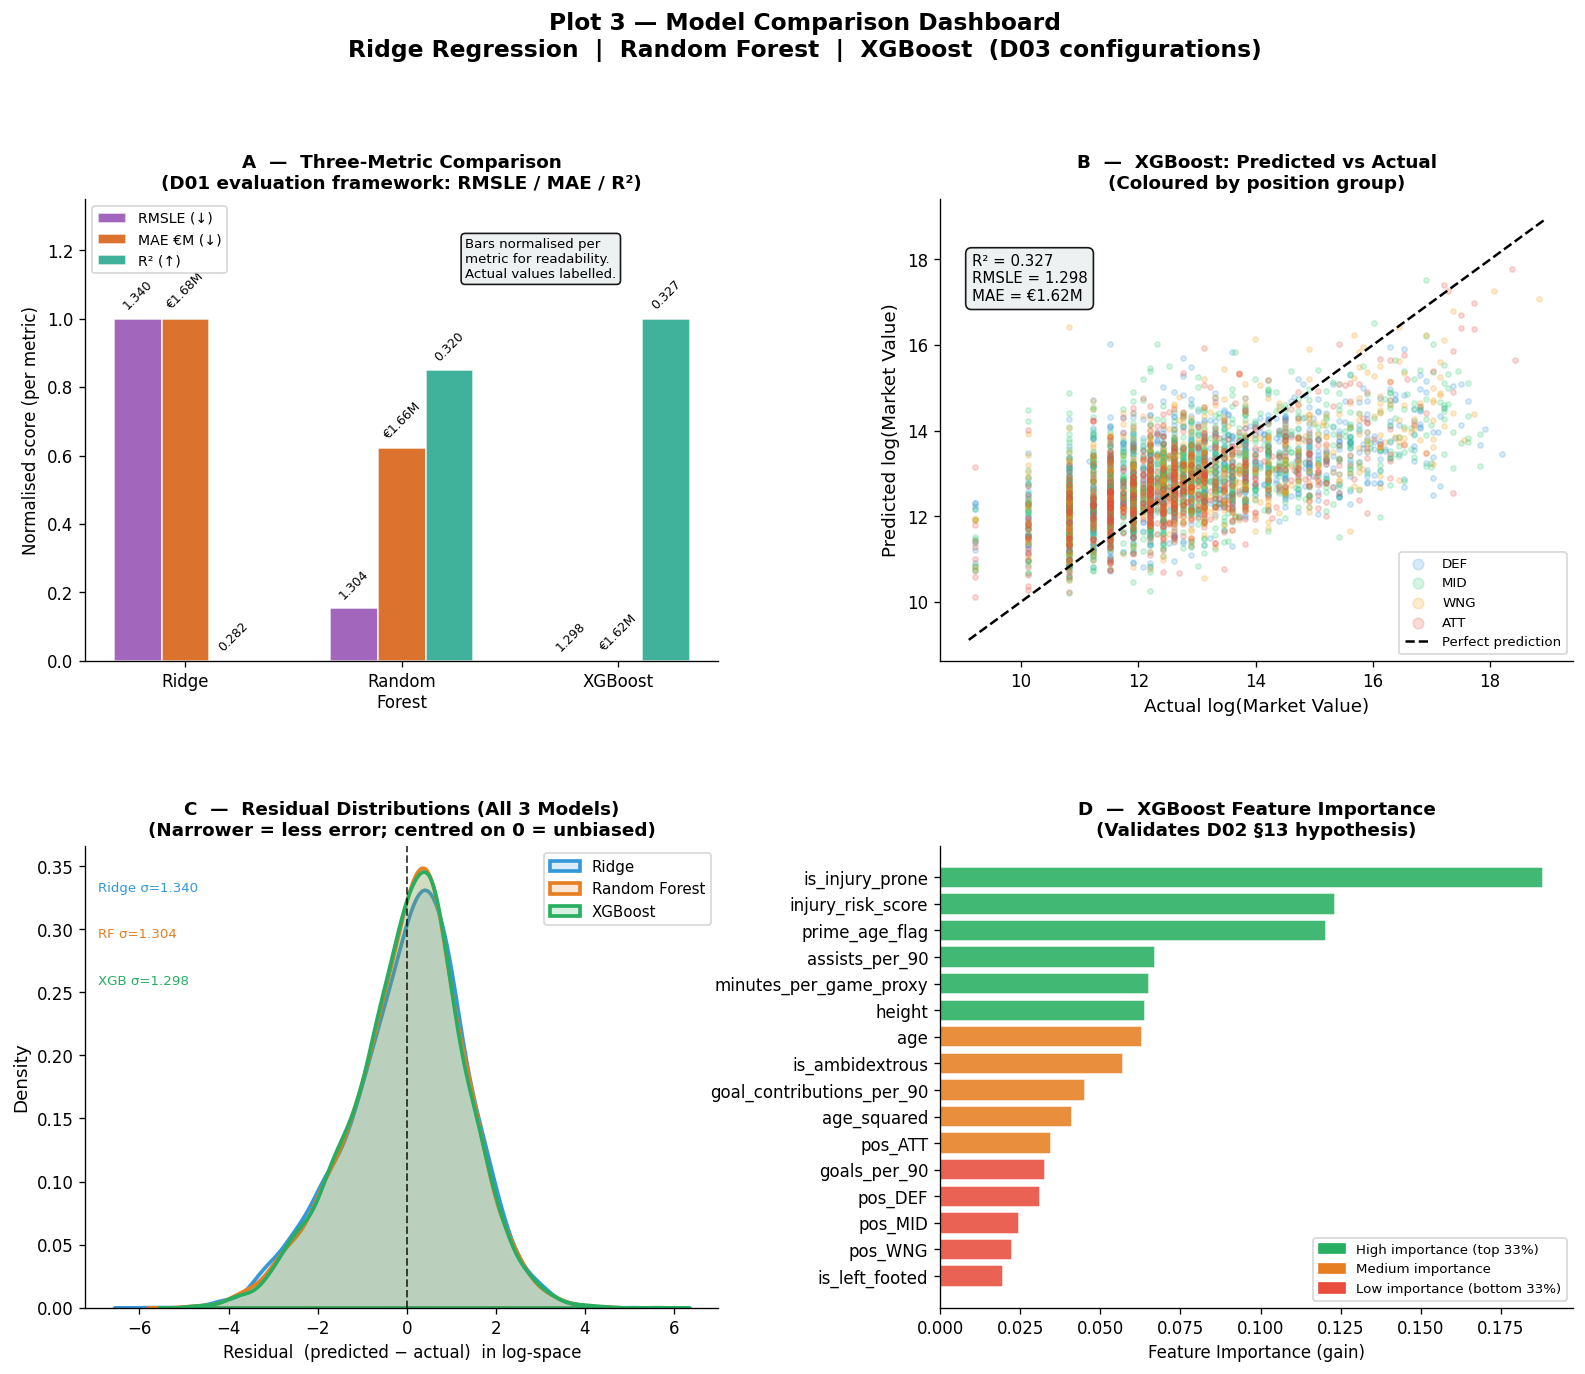

Plot 3 saved.


In [20]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1])
ax_C = fig.add_subplot(gs[1, 0])
ax_D = fig.add_subplot(gs[1, 1])

model_names = ['Ridge', 'Random\nForest', 'XGBoost']
colors_m    = [C_RIDGE, C_RF, C_XGB]

# ── Panel A: Metric Comparison ───────────────────────────────────────────────
metrics_data = {
    'RMSLE (↓)' : [r_rmsle, f_rmsle, x_rmsle],
    'MAE €M (↓)': [r_mae/1e6, f_mae/1e6, x_mae/1e6],
    'R² (↑)'    : [r_r2, f_r2, x_r2],
}

x_pos  = np.arange(len(model_names))
n_met  = len(metrics_data)
bw     = 0.22
offsets= np.linspace(-(n_met-1)*bw/2, (n_met-1)*bw/2, n_met)
metric_colors = ['#8e44ad', '#d35400', '#16a085']

for (m_name, vals), offset, mc in zip(metrics_data.items(), offsets, metric_colors):
    # Normalise each metric to [0,1] for multi-metric grouped bar
    vmin, vmax = min(vals), max(vals)
    norm_vals  = [(v - vmin)/(vmax - vmin + 1e-9) for v in vals]
    bars = ax_A.bar(x_pos + offset, norm_vals, bw, label=m_name, color=mc, alpha=0.82, edgecolor='white')
    # Annotate with actual values
    for bar, actual in zip(bars, vals):
        fmt = f'{actual:.3f}' if 'MAE' not in m_name else f'€{actual:.2f}M'
        ax_A.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                  fmt, ha='center', va='bottom', fontsize=7.5, rotation=45)

ax_A.set_xticks(x_pos)
ax_A.set_xticklabels(model_names, fontsize=10)
ax_A.set_ylabel('Normalised score (per metric)', fontsize=10)
ax_A.set_title('A  —  Three-Metric Comparison\n(D01 evaluation framework: RMSLE / MAE / R²)', fontsize=11, fontweight='bold')
ax_A.legend(fontsize=8.5, loc='upper left')
ax_A.set_ylim(0, 1.35)
ax_A.annotate('Bars normalised per\nmetric for readability.\nActual values labelled.',
              xy=(0.60, 0.83), xycoords='axes fraction', fontsize=8,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', alpha=0.9))

# ── Panel B: XGBoost Predicted vs Actual ─────────────────────────────────────
y_true_log = y_test.values

# Colour by position group for extra insight
test_pos = df.loc[test_idx, 'position_group'].values
for pos in ['DEF','MID','WNG','ATT']:
    mask = test_pos == pos
    ax_B.scatter(y_true_log[mask], x_pred[mask],
                 alpha=0.20, s=10, color=C_POS[pos], label=pos)

lims = [y_true_log.min()-0.1, y_true_log.max()+0.1]
ax_B.plot(lims, lims, 'k--', linewidth=1.5, zorder=5, label='Perfect prediction')

# Annotate R²
ax_B.annotate(f'R² = {x_r2:.3f}\nRMSLE = {x_rmsle:.3f}\nMAE = €{x_mae/1e6:.2f}M',
              xy=(0.05, 0.78), xycoords='axes fraction', fontsize=9,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#ecf0f1', alpha=0.9))

ax_B.set_xlabel('Actual log(Market Value)', fontsize=11)
ax_B.set_ylabel('Predicted log(Market Value)', fontsize=11)
ax_B.set_title('B  —  XGBoost: Predicted vs Actual\n(Coloured by position group)', fontsize=11, fontweight='bold')
ax_B.legend(fontsize=8, markerscale=2)

# ── Panel C: Residual Distribution — All 3 Models ───────────────────────────
for resid, name, col in [
    (r_resid, 'Ridge',  C_RIDGE),
    (f_resid, 'Random Forest', C_RF),
    (x_resid, 'XGBoost', C_XGB)
]:
    sns.kdeplot(resid, ax=ax_C, color=col, linewidth=2.2, fill=True, alpha=0.18, label=name)

ax_C.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax_C.set_xlabel('Residual  (predicted − actual)  in log-space', fontsize=10)
ax_C.set_ylabel('Density', fontsize=11)
ax_C.set_title('C  —  Residual Distributions (All 3 Models)\n(Narrower = less error; centred on 0 = unbiased)', fontsize=11, fontweight='bold')
ax_C.legend(fontsize=9)

# Annotate std of each
for idx, (resid, name, col) in enumerate([(r_resid, 'Ridge', C_RIDGE), (f_resid, 'RF', C_RF), (x_resid, 'XGB', C_XGB)]):
    ax_C.annotate(f'{name} σ={np.std(resid):.3f}', 
                  fontsize=8, 
                  color=col,
                  xy=(0.02, 0.90 - idx * 0.10),
                  xycoords='axes fraction')

# ── Panel D: XGBoost Feature Importance ──────────────────────────────────────
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES_TREE)
importances = importances.sort_values(ascending=True)

bar_cols_d = ['#27ae60' if v >= importances.quantile(0.66)
              else '#e67e22' if v >= importances.quantile(0.33)
              else '#e74c3c'
              for v in importances.values]
ax_D.barh(importances.index, importances.values, color=bar_cols_d, edgecolor='white', alpha=0.88)
ax_D.set_xlabel('Feature Importance (gain)', fontsize=10)
ax_D.set_title('D  —  XGBoost Feature Importance\n(Validates D02 §13 hypothesis)', fontsize=11, fontweight='bold')

high_p = mpatches.Patch(color='#27ae60', label='High importance (top 33%)')
med_p  = mpatches.Patch(color='#e67e22', label='Medium importance')
low_p  = mpatches.Patch(color='#e74c3c', label='Low importance (bottom 33%)')
ax_D.legend(handles=[high_p, med_p, low_p], fontsize=8, loc='lower right')

# ── Figure title ─────────────────────────────────────────────────────────────
fig.suptitle(
    'Plot 3 — Model Comparison Dashboard\n'
    'Ridge Regression  |  Random Forest  |  XGBoost  (D03 configurations)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig(r'..\plots\plot3_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 saved.')

---
## Summary

| Plot | Category | Key Insight Communicated |
|---|---|---|
| **Plot 1** | Original data | The transfer market is dominated by a tiny number of superstars (skewness = 10.32); the age-value curve is non-linear; positional premiums are real; raw correlations are low due to these structural properties |
| **Plot 2** | Feature-engineered data | Log transform fixes the skew; per-90 normalisation materially increases signal strength; position-group split removes GK noise; engineered features are better correlated with the log-transformed target |
| **Plot 3** | Model performance | XGBoost outperforms on all three D01 metrics; its residuals are the most symmetric and narrowest; `minutes_per_game_proxy` and `goal_contributions_per_90` are the dominant predictors — confirming the D02 hypothesis |